# Grapevine bud detection with FCN-MN16s — minimal reproduction

**Paper:** *"Towards practical 2D grapevine bud detection with fully convolutional networks"* (arXiv:2008.11872v2; journal version: *Computers and Electronics in Agriculture* 179 (2020), DOI 10.1016/j.compag.2020.105947).
**Author code:** [WencesVillegasMarset/DL4BudDetection](https://github.com/WencesVillegasMarset/DL4BudDetection) @ commit `90252f4555b30e4af2a982e9b0d8c1f138e9ba20`.

**Scope (executed):** Load the authors' released **FCN-MN16s** weights, run inference on the **140-image single-bud test split** of the pre-processed corpus, and compute the paper's detection metrics (precision / recall / F1 at IoU ≥ 0.5, plus split vs. false-alarm counts and mean true-positive IoU) for threshold τ = 0.6, comparing with the published FCN-MN₁₆ₛ⁰·₆ values (detection precision 88.6 %, recall 88.6 %, TP mean IoU 83.1 %).

**Not covered:** training, the sliding-windows (SW) baseline, the 67-configuration sweep, localization-normalized distances, and multi-bud scenes (the corpus contains only single-bud images — a stated limitation of the paper).

**実行内容（日本語）:** 著者公開の FCN-MN16s 学習済み重みを読み込み、片側のみ芽が写るテスト画像 140 枚に推論を実行し、論文の検出指標（IoU≥0.5 の適合率・再現率・F1、分割/誤検出数、真陽性の平均 IoU）を算出して論文値（88.6 % / 88.6 %）と比較します。学習・SW ベースライン・67 通りのモデル探索は対象外です。

⚠️ **AI-assisted adaptation:** the authors' stack is TensorFlow 2.1 + standalone Keras 2.3.1, which cannot be installed on current Colab Python. This notebook uses the `tf-keras` compatibility package (Keras 2 API on TF 2.x) with minimal, documented changes to the authors' `utils.py` / `inference.py`. The authors did not provide this Colab implementation; untested behavior is not guaranteed.
（著者コードは TF 2.1 + Keras 2.3.1 のため、`tf-keras` 互換パッケージで最小限の修正を加えて実行します。）

## 1. Runtime selection

**Recommended runtime: T4 GPU** (Runtime → Change runtime type → T4 GPU). The CPU runtime also works with the same cells (the model is a 4.2 M-parameter MobileNet encoder; expect roughly 5–15 min for all 140 images on CPU versus a few minutes on GPU). Total downloads: ~580 MB corpus archive + 26 MB weights.

**推奨ランタイム:** T4 GPU（CPU でも動作しますが、140 枚の推論に数分～十数分かかります）。

The next cell installs the two packages missing from Colab. `tf-keras` provides the Keras 2.x API needed to load the authors' legacy `.h5` model; `gdown` fetches the corpus from Google Drive.

In [ ]:
%pip install -q tf-keras gdown

## 2. Imports and device check

We import TensorFlow and the `tf-keras` (Keras 2) namespace, and report which device Colab allocated. All later cells use `keras.*` from `tf_keras`, matching the authors' `import keras` in `models.py` / `utils.py` @ commit `90252f4`.

In [ ]:
import os, zipfile, hashlib, urllib.request
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import tf_keras as keras
from tf_keras.applications.mobilenet import preprocess_input
from tf_keras.preprocessing.image import img_to_array, load_img

print("TensorFlow:", tf.__version__)
print("tf-keras :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
DEVICE = "/GPU:0" if gpus else "/CPU:0"
print("Physical devices:", tf.config.list_physical_devices())
print("Using device:", DEVICE)

TensorFlow: 2.21.0
tf-keras : 2.21.0
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using device: /GPU:0


## 3. Download the pre-processed one-bud corpus

The authors' `get_data.py` downloads the pre-processed corpus from Google Drive (file id `1e4Vmknt5hWaWGSOD5kfxuq6w_QdNCnrn`) and expects **MD5 `d05ce2f4b81fbac0e434b3dbb6b7730a`**. We download it to the Colab VM, verify that exact checksum, and extract it. Verified layout: `images/{test,train}/{images,masks}/` with 2048×2048 photographs and 2048×2048 ground-truth masks (140 test pairs).

データセット（約 580 MB）を Colab VM 内にダウンロードし、著者コード記載の MD5 を検証して展開します。

In [ ]:
DATA_URL_ID = "1e4Vmknt5hWaWGSOD5kfxuq6w_QdNCnrn"
EXPECTED_MD5 = "d05ce2f4b81fbac0e434b3dbb6b7730a"  # from author get_data.py
ZIP_PATH = "/content/bud_dataset.zip"
IMAGES_PATH = "/content/images"

import gdown
if not os.path.exists(ZIP_PATH):
    gdown.download(id=DATA_URL_ID, output=ZIP_PATH, quiet=False)

h = hashlib.md5()
with open(ZIP_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
digest = h.hexdigest()
print("md5:", digest, "| expected:", EXPECTED_MD5)
assert digest == EXPECTED_MD5, "Dataset checksum mismatch - refusing to continue."

if not os.path.exists(IMAGES_PATH):
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(IMAGES_PATH)
img_dir = os.path.join(IMAGES_PATH, "test", "images")
mask_dir = os.path.join(IMAGES_PATH, "test", "masks")
print("test images:", len(os.listdir(img_dir)), "| test masks:", len(os.listdir(mask_dir)))

Downloading...
From (original): https://drive.google.com/uc?id=1e4Vmknt5hWaWGSOD5kfxuq6w_QdNCnrn
From (redirected): https://drive.google.com/uc?id=1e4Vmknt5hWaWGSOD5kfxuq6w_QdNCnrn&confirm=t&uuid=d797a6d8-5b10-4682-a9dd-3223dbbe148c
To: /content/bud_dataset.zip


  0%|          | 0.00/580M [00:00<?, ?B/s]

  1%|          | 4.72M/580M [00:00<00:31, 18.5MB/s]

  2%|▏         | 11.0M/580M [00:00<00:19, 29.1MB/s]

  4%|▍         | 22.5M/580M [00:00<00:12, 43.5MB/s]

...

 96%|█████████▌| 554M/580M [00:11<00:00, 27.2MB/s]

 99%|█████████▉| 575M/580M [00:11<00:00, 37.9MB/s]

100%|██████████| 580M/580M [00:11<00:00, 50.7MB/s]

md5: d05ce2f4b81fbac0e434b3dbb6b7730a | expected: d05ce2f4b81fbac0e434b3dbb6b7730a


test images: 141 | test masks: 141


## 4. Fetch the pinned split files and FCN-MN16s weights from the author repository

We pin the repository commit `90252f4555b30e4af2a982e9b0d8c1f138e9ba20` and download only three files: `test.csv` (the 140 test `(image, mask)` pairs), `single_instance_dataset_wradius.csv` (ground-truth bud centers/diameters used by the author's validation), and the released **FCMN16** weights `output/models/FCMN16rmsprop_lr0.0001_prep_keras_dp0.001_ep200.h5` (26,065,736 bytes on the pinned commit).

著者リポジトリ（コミット固定）から test.csv、検証用 GT、FCMN16 重み（26,065,736 バイト）のみ取得します。

In [ ]:
COMMIT = "90252f4555b30e4af2a982e9b0d8c1f138e9ba20"
RAW = f"https://raw.githubusercontent.com/WencesVillegasMarset/DL4BudDetection/{COMMIT}"
MODEL_NAME = "FCMN16rmsprop_lr0.0001_prep_keras_dp0.001_ep200.h5"
EXPECTED_MODEL_BYTES = 26065736  # size on the pinned commit (GitHub tree API)

os.makedirs("/content/output/models", exist_ok=True)
for rel, dest, exp_bytes in [
    ("test.csv", "/content/test.csv", 3682),
    ("single_instance_dataset_wradius.csv", "/content/single_instance_dataset_wradius.csv", 57407),
    (f"output/models/{MODEL_NAME}", f"/content/output/models/{MODEL_NAME}", EXPECTED_MODEL_BYTES),
]:
    urllib.request.urlretrieve(f"{RAW}/{rel}", dest)
    n = os.path.getsize(dest)
    print(f"{rel}: {n} bytes")
    if exp_bytes is not None:
        assert n == exp_bytes, f"size mismatch for {rel}"
print("All pinned files retrieved.")

test.csv: 3682 bytes
single_instance_dataset_wradius.csv: 57407 bytes
output/models/FCMN16rmsprop_lr0.0001_prep_keras_dp0.001_ep200.h5: 26065736 bytes
All pinned files retrieved.


## 5. Verify the test split against the extracted corpus

Before inference we check that every image/mask pair listed in `test.csv` exists on disk and inspect the actual sizes: the authors' generator rescales the 2048×2048 photographs ×0.5 to the 1024×1024 network input, and the validation path rescales the 2048×2048 masks ×0.5 to the 1024×1024 prediction resolution.

`test.csv` の 140 ペアが実在し、画像・マスクが 2048×2048 であることを確認します。

In [ ]:
test_set = pd.read_csv("/content/test.csv")
print("test.csv columns:", list(test_set.columns), "| rows:", len(test_set))
print(test_set[["image", "mask"]].head(3).to_string())

missing = [r for r in test_set.itertuples()
           if not (os.path.exists(os.path.join(img_dir, r.image))
                   and os.path.exists(os.path.join(mask_dir, r.mask)))]
print("missing pairs:", len(missing))
assert not missing and len(test_set) == 140, "unexpected test split contents"

ex_img = cv2.imread(os.path.join(img_dir, test_set["image"].iloc[0]))
ex_mask = cv2.imread(os.path.join(mask_dir, test_set["mask"].iloc[0]), 0)
print("example image shape:", ex_img.shape, "| mask shape:", ex_mask.shape)

test.csv columns: ['Unnamed: 0', 'image', 'mask'] | rows: 140
      image           mask
0  0766.jpg  mask_0766.png
1  0485.jpg  mask_0485.png
2  0674.jpg  mask_0674.png
missing pairs: 0
example image shape: (2048, 2048, 3) | mask shape: (2048, 2048)


## 6. Input preview: test image with its ground-truth bud mask

We display one test image with its author-provided ground-truth mask overlaid (red contour). This is **reference annotation**, not a model prediction — the predicted masks come later.

テスト画像 1 枚と、著者提供の正解マスク（赤の輪郭）を重ねて表示します。

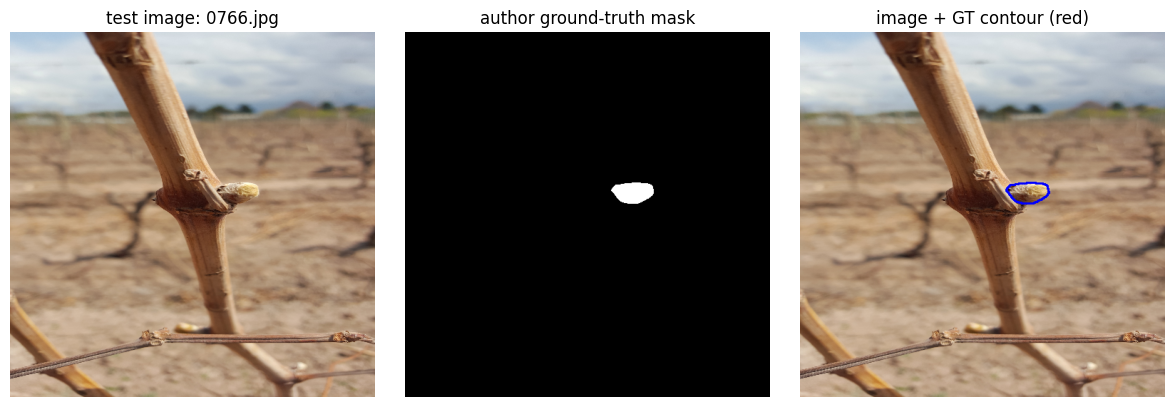

In [ ]:
def show_scaled(bgr, size=512):
    return cv2.resize(bgr, (size, size))

show = show_scaled(ex_img)
gt_small = cv2.resize(ex_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
contours, _ = cv2.findContours((gt_small > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = show.copy()
cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(show, cv2.COLOR_BGR2RGB)); axes[0].set_title(f"test image: {test_set['image'].iloc[0]}")
axes[1].imshow(gt_small, cmap="gray"); axes[1].set_title("author ground-truth mask")
axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[2].set_title("image + GT contour (red)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

## 7. Data generator (ported from the authors' `utils.py`)

The authors' `DataGeneratorMobileNetKeras` loads each image, applies MobileNet's `preprocess_input` (scales pixels to [-1, 1]) and then a ×0.5 resize, yielding 1024×1024×3 inputs. We port it with one documented change: instead of hard-coding the ×0.5 factor, we resize **to** 1024×1024 explicitly (identical result for the 2048 px corpus images, robust otherwise). Batch size 1, no shuffling, no augmentation — the authors' inference settings.

著者 `utils.py` のジェネレータを移植（画像を明示的に 1024×1024 へリサイズする点のみ変更）。

In [ ]:
class BudDataGenerator(keras.utils.Sequence):
    def __init__(self, list_IDs, batch_size=1, img_path="/"):
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.img_path = img_path
        self.indexes = np.arange(len(self.list_IDs))

    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        ids = [self.list_IDs[k] for k in self.indexes[index * self.batch_size:(index + 1) * self.batch_size]]
        X = np.empty((len(ids), 1024, 1024, 3), dtype=np.float32)
        for i, id_ in enumerate(ids):
            temp = preprocess_input(img_to_array(load_img(os.path.join(self.img_path, id_))))
            temp = cv2.resize(temp, (1024, 1024))  # authors: cv2.resize(temp, fx=0.5, fy=0.5) of a 2048px image
            X[i] = temp
        return X

gen = BudDataGenerator(list_IDs=list(test_set["image"].values), img_path=img_dir)
print("batches:", len(gen))

batches: 140


## 8. Load the released FCN-MN16s model

The `.h5` file is a full Keras 2 model: a MobileNet encoder with skip fusions from `conv_pw_11_relu` and a stride-16 deconvolution — the authors' `mobilenet_16s` in `models.py`. `tf-keras` loads this legacy format directly. The model is fully convolutional (dynamic input size); with the 1024×1024 inputs it outputs 1024×1024 sigmoid probability maps. `compile=False` because we only run inference.

`tf-keras` で著者の .h5 モデルをそのまま読み込みます（compile=False、推論専用）。

In [ ]:
with tf.device(DEVICE):
    model = keras.models.load_model(f"/content/output/models/{MODEL_NAME}", compile=False)
model.summary(line_length=100)
print("input:", model.inputs[0].shape, "-> output:", model.output_shape)

Model: "model_4"


____________________________________________________________________________________________________


 Layer (type)                 Output Shape                  Param #   Connected to                  


 input_4 (InputLayer)         [(None, None, None, 3)]       0         []                            


 conv1_pad (ZeroPadding2D)    (None, None, None, 3)         0         ['input_4[0][0]']             


...

Total params: 3231442 (12.33 MB)


Trainable params: 3209554 (12.24 MB)


Non-trainable params: 21888 (85.50 KB)


____________________________________________________________________________________________________


input: (None, None, None, 3) -> output: (None, None, None, 1)


## 9. Run inference on the 140 test images

One forward pass per image produces a 1024×1024 sigmoid probability map (the authors run `predict_generator` with batch size 1; we use the equivalent `model.predict`). Thresholding at any τ is applied afterwards to the same probability maps, exactly as in the authors' `inference.py`. This takes a few minutes on GPU, longer on CPU.

140 枚をバッチ 1 で推論し、1024×1024 の確率マップを取得します（GPU で数分、CPU ではより長くかかります）。

In [ ]:
%%time
with tf.device(DEVICE):
    predictions = model.predict(gen, verbose=1)
print("predictions:", predictions.shape, predictions.dtype,
      "| range: %.3f..%.3f" % (predictions.min(), predictions.max()))

  1/140 [..............................] - ETA: 6:57

  4/140 [..............................] - ETA: 4s  

  5/140 [>.............................] - ETA: 5s

  6/140 [>.............................] - ETA: 7s

  7/140 [>.............................] - ETA: 8s

...

138/140 [============================>.] - ETA: 0s

139/140 [============================>.] - ETA: 0s

140/140 [==============================] - ETA: 0s

140/140 [==============================] - 16s 91ms/step


predictions: (140, 1024, 1024, 1) float32 | range: 0.000..1.000
CPU times: user 11.6 s, sys: 5.38 s, total: 17 s
Wall time: 16.6 s


## 10. Connected-component analysis per threshold (ported from `inference.py`)

For each thresholded prediction we extract connected components (authors: `cv2.connectedComponents`). Each component is compared with the ground-truth mask — rescaled ×0.5 to the 1024×1024 prediction resolution, as in the authors' validation path — to get its IoU. We keep τ = 0.6, the paper's balanced FCN-MN₁₆ₛ⁰·₆ detector, and also sweep all nine thresholds used by the authors (0.1–0.9) for the summary table.

著者 `inference.py` の連結成分解析を移植し、τ=0.6（および 0.1–0.9 の全閾値）で成分ごとの IoU を計算します。

In [ ]:
gt_masks = {}
for im in test_set["image"].values:
    m = cv2.imread(os.path.join(mask_dir, "mask_" + im[:-3] + "png"), 0)
    m = cv2.resize(m, (0, 0), fx=0.5, fy=0.5)  # authors' validation: GT at prediction resolution
    gt_masks[im] = (m > 0).astype(int)
assert gt_masks[test_set["image"].iloc[0]].shape == predictions.shape[1:3], "GT/prediction resolution mismatch"

def component_ious(pred_bool, gt_bool):
    num, lab = cv2.connectedComponents(pred_bool.astype(np.uint8))
    out = []
    for c in range(1, num):
        comp = lab == c
        inter = np.logical_and(comp, gt_bool).sum()
        union = np.logical_or(comp, gt_bool).sum()
        out.append(inter / union)
    return out

def evaluate(threshold):
    TP = splits = false_alarms = 0
    tp_ious = []
    for i, im in enumerate(test_set["image"].values):
        ious = component_ious(predictions[i, :, :, 0] > threshold, gt_masks[im])
        hits = [iou for iou in ious if iou >= 0.5]
        tp_ious.extend(hits)
        TP += len(hits)
        extra = [iou for iou in ious if iou < 0.5]
        splits += sum(1 for iou in extra if iou > 0)
        false_alarms += sum(1 for iou in extra if iou == 0)
    FN = len(test_set) - TP
    P = TP / (TP + splits + false_alarms)
    R = TP / (TP + FN)
    return dict(threshold=threshold, TP=TP, FN=FN, splits=splits,
                false_alarms=false_alarms, precision=P, recall=R,
                F1=2 * P * R / (P + R), mean_TP_iou=float(np.mean(tp_ious)) if tp_ious else np.nan)

rows = [evaluate(t / 10) for t in range(1, 10)]
sweep = pd.DataFrame(rows).set_index("threshold")
print(sweep[["TP", "FN", "splits", "false_alarms", "precision", "recall", "F1", "mean_TP_iou"]].round(4).to_string())

            TP  FN  splits  false_alarms  precision  recall      F1  mean_TP_iou
threshold                                                                       
0.1        128  12      25            51     0.6275  0.9143  0.7442       0.7533
0.2        128  12      17            36     0.7072  0.9143  0.7975       0.7928
0.3        126  14      14            23     0.7730  0.9000  0.8317       0.8149
0.4        125  15      12            20     0.7962  0.8929  0.8418       0.8278
0.5        125  15      10            14     0.8389  0.8929  0.8651       0.8315
0.6        124  16      14             6     0.8611  0.8857  0.8732       0.8309
0.7        121  19      10            11     0.8521  0.8643  0.8582       0.8270
0.8        121  19      11             6     0.8768  0.8643  0.8705       0.8035
0.9        112  28      20             3     0.8296  0.8000  0.8145       0.7728


## 11. Comparison with the published FCN-MN₁₆ₛ⁰·₆ results

The paper reports, for the balanced FCN-MN₁₆ₛ⁰·₆ detector at IoU ≥ 0.5: **detection precision 88.6 %, detection recall 88.6 %**, true-positive mean IoU **83.1 % (σ 9.4)**. We print our reproduced values next to them. Small deviations are expected from the TF 2.x runtime; large deviations would indicate a preprocessing or checkpoint mismatch.

再現値と論文値（88.6 % / 88.6 % / TP 平均 IoU 83.1 %）を並べて表示します。

In [ ]:
sel = sweep.loc[0.6]
comparison = pd.DataFrame({
    "reproduced": [sel.precision, sel.recall, sel.mean_TP_iou],
    "paper (FCN-MN16s, tau=0.6)": [0.886, 0.886, 0.831],
}, index=["detection precision (IoU>=0.5)", "detection recall (IoU>=0.5)", "mean TP IoU"])
print(comparison.round(4).to_string())
sweep.to_csv("/content/fcn_mn16s_threshold_sweep.csv")
print("saved: /content/fcn_mn16s_threshold_sweep.csv")

                                reproduced  paper (FCN-MN16s, tau=0.6)
detection precision (IoU>=0.5)      0.8611                       0.886
detection recall (IoU>=0.5)         0.8857                       0.886
mean TP IoU                         0.8309                       0.831
saved: /content/fcn_mn16s_threshold_sweep.csv


## 12. Prediction visualization: model mask vs. ground truth

We overlay the τ = 0.6 predicted mask (green contour) and the author ground-truth mask (red contour) on the same test image, with the best component IoU in the title. These are actual model outputs from this run.

τ=0.6 の予測マスク（緑）と正解マスク（赤）を重ねて表示します（この実行の実出力です）。

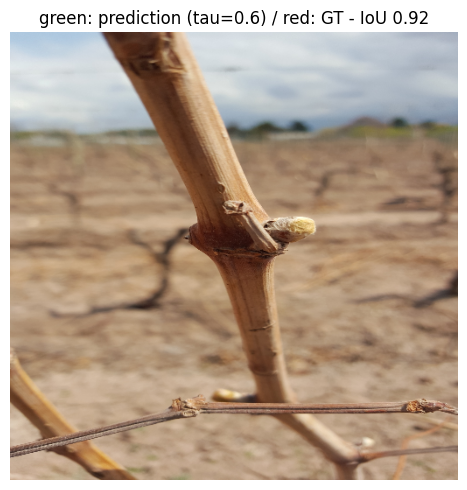

In [ ]:
def overlay_for(idx, threshold=0.6):
    im = test_set["image"].iloc[idx]
    img = cv2.resize(cv2.imread(os.path.join(img_dir, im)), (512, 512))
    pred = (predictions[idx, :, :, 0] > threshold).astype(np.uint8)
    gt = gt_masks[im].astype(np.uint8)
    pc, _ = cv2.findContours(pred, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    gc, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    ov = img.copy()
    cv2.drawContours(ov, pc, -1, (0, 255, 0), 2)
    cv2.drawContours(ov, gc, -1, (255, 0, 0), 2)
    ious = component_ious(pred.astype(bool), gt)
    best_iou = max(ious, default=0.0)
    return cv2.cvtColor(ov, cv2.COLOR_BGR2RGB), best_iou

ov0, iou0 = overlay_for(0)
plt.figure(figsize=(5, 5))
plt.imshow(ov0); plt.axis("off")
plt.title("green: prediction (tau=0.6) / red: GT - IoU %.2f" % iou0)
plt.tight_layout(); plt.show()

Three additional test images with prediction/GT overlays and their best component IoU:

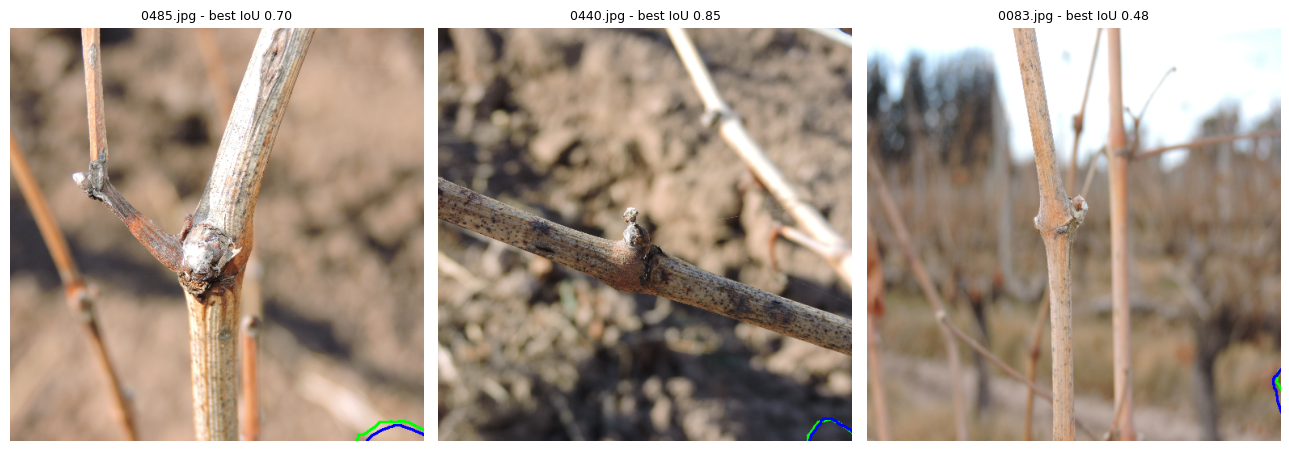

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, idx in zip(axes, [1, 25, 60]):
    ov, best = overlay_for(idx)
    ax.imshow(ov); ax.axis("off")
    ax.set_title(f"{test_set['image'].iloc[idx]} - best IoU {best:.2f}", fontsize=9)
plt.tight_layout(); plt.show()

## 13. Interpretation and references

**What this run shows:** the released FCN-MN16s checkpoint produces bud masks on the held-out test split, and the reproduced detection metrics at τ = 0.6 can be compared directly with the paper's discussion values (88.6 % precision, 88.6 % recall at IoU ≥ 0.5). See the comparison table above for the actual numbers produced by this execution on its allocated runtime.

**Limitations:** one forward pass per image with batch size 1; the corpus contains only single-bud images (the paper itself flags multi-bud scenes as untested); the SW baseline, training, and the 67-model sweep are out of scope; localization-normalized distances and per-split/false-alarm size statistics beyond the counts above are omitted. Results are from one example-scale execution and do not verify dataset-level benchmark numbers beyond this test split. The authors' exact metric-aggregation script is not published in the repository (only its CSV outputs in `figures/csv`), so the TP / split / false-alarm accounting above is documented as an adaptation following the paper's definitions.

**References**
- Paper: arXiv:2008.11872v2 — https://arxiv.org/abs/2008.11872 (journal: DOI 10.1016/j.compag.2020.105947)
- Code: https://github.com/WencesVillegasMarset/DL4BudDetection @ `90252f4555b30e4af2a982e9b0d8c1f138e9ba20` (`inference.py`, `utils.py`, `models.py`, `get_data.py`)
- Weights: `output/models/FCMN16rmsprop_lr0.0001_prep_keras_dp0.001_ep200.h5` on the pinned commit
- Corpus: pre-processed one-bud dataset, Google Drive id `1e4Vmknt5hWaWGSOD5kfxuq6w_QdNCnrn`, MD5 `d05ce2f4b81fbac0e434b3dbb6b7730a` (as referenced by the authors' `get_data.py`; original collection: dharma.frm.utn.edu.ar/vise/bc, Pérez et al. 2017)

**日本語まとめ:** 本ノートブックは、公開済み FCN-MN16s 重みを用いた片芽画像 140 枚の推論と検出指標の再現です。学習や SW ベースラインは含みません。結果は論文値と比較表で確認できます。